# Урок 2.4. Дерево как слабый ученик

**Интерактивная версия:** `lessons/lesson_2_4/web/index.html`

1. Нет экстраполяции.
2. Неустойчивость к одной точке.
3. Лесенка и сумма лесенок.
4. Глубина = порядок взаимодействий.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from gbcourse import datasets, RegressionTree, GBRegressor
from gbcourse.plotting import use_course_style, plot_data

use_course_style()
grid = np.linspace(0, 10, 500).reshape(-1, 1)

## 1. Нет экстраполяции

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


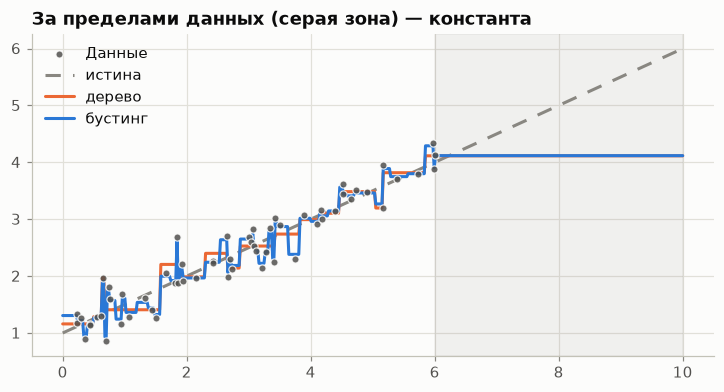

In [2]:
X, y = datasets.regression_1d(kind="linear", n=60, noise=0.3, seed=8, x_max=6.0)
tree = RegressionTree(max_depth=4).fit(X, -y)
gb = GBRegressor(n_estimators=300, learning_rate=0.1, max_depth=2).fit(X, y)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.axvspan(6, 10, color="#898781", alpha=0.1)
plot_data(ax, X, y)
ax.plot(grid, 0.5 * grid + 1, color="#898781", ls=(0, (5, 4)), label="истина")
ax.plot(grid, tree.predict(grid), color="#eb6834", label="дерево")
ax.plot(grid, gb.predict(grid), color="#2a78d6", label="бустинг")
ax.set_title("За пределами данных (серая зона) — константа")
ax.legend()
plt.show()

## 2. Неустойчивость: одна точка меняет дерево

In [3]:
X, y = datasets.regression_1d(kind="sine", n=40, noise=0.3, seed=12)
base = RegressionTree(max_depth=3).fit(X, -y)
for shift in (0.0, 1.0, 2.0, 3.0):
    y2 = y.copy()
    y2[19] += shift
    t = RegressionTree(max_depth=3).fit(X, -y2)
    thr = sorted(round(nd.threshold, 2) for nd in t.nodes if not nd.is_leaf)
    print(f"сдвиг точки #19 на {shift:+.1f}: пороги {thr}")

сдвиг точки #19 на +0.0: пороги [0.42, 1.04, 2.59, 2.77, 3.67, 6.29, 9.1]
сдвиг точки #19 на +1.0: пороги [0.42, 1.04, 2.59, 2.77, 4.0, 6.29, 9.1]
сдвиг точки #19 на +2.0: пороги [0.42, 1.04, 2.43, 2.59, 4.0, 6.46, 9.1]
сдвиг точки #19 на +3.0: пороги [0.42, 1.04, 2.43, 2.59, 4.0, 6.46, 9.1]


## 3. Лесенка и сумма лесенок

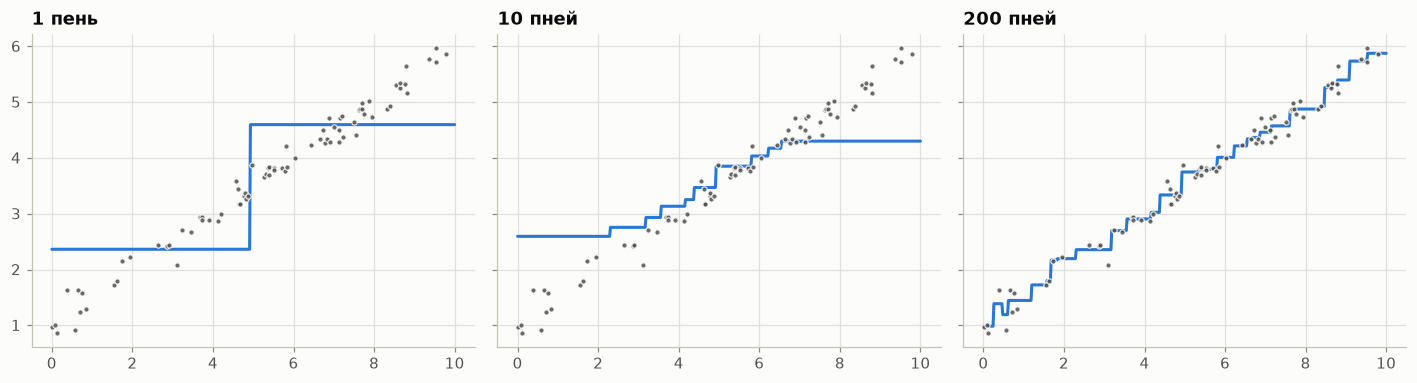

In [4]:
X, y = datasets.regression_1d(kind="linear", n=80, noise=0.15, seed=3)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, M in zip(axes, (1, 10, 200)):
    m = GBRegressor(n_estimators=M, learning_rate=0.1 if M > 1 else 1.0, max_depth=1).fit(X, y)
    plot_data(ax, X, y, label=None, s=12)
    ax.plot(grid, m.predict(grid), color="#2a78d6")
    ax.set_title(f"{M} {'пень' if M == 1 else 'пней'}")
plt.tight_layout()
plt.show()

## 4. Глубина = порядок взаимодействий

Цель $y = x_0 \cdot x_1$ — чистое взаимодействие. Бустинг из пней выражает только $f_0(x_0) + f_1(x_1)$.

In [5]:
rng_X = datasets.friedman1(n=800, noise=0.0, seed=5, n_features=5)[0][:, :2] * 2 - 1
y_int = rng_X[:, 0] * rng_X[:, 1]
Xtr, Xte, ytr, yte = datasets.train_test_split(rng_X, y_int, test_size=0.3, seed=0)
for d in (1, 2, 3):
    m = GBRegressor(n_estimators=300, learning_rate=0.1, max_depth=d).fit(Xtr, ytr)
    print(f"глубина {d}: MSE на тесте {np.mean((yte - m.predict(Xte)) ** 2):.4f} (дисперсия y = {yte.var():.4f})")

глубина 1: MSE на тесте 0.1271 (дисперсия y = 0.1075)
глубина 2: MSE на тесте 0.0091 (дисперсия y = 0.1075)


глубина 3: MSE на тесте 0.0025 (дисперсия y = 0.1075)


Пни не могут выучить произведение признаков — их MSE почти равна дисперсии цели.

## Упражнения

1. Предложите способ научить бустинг экстраполировать линейный тренд (подсказка: вычтите тренд из y).
2. Посчитайте, как часто корневой порог дерева глубины 3 меняется при бутстрэп-выборках (50 повторов).
3. Для цели $y = x_0 x_1 x_2$ сравните бустинг глубины 2 и 3.

Решения: `python lessons/lesson_2_4/exercises/solutions.py`.